In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().absolute().parent.parent.parent))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
from pathlib import Path

rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
    'pgf.texsystem': 'pdflatex',
    'pgf.preamble': '',
    "font.family": "serif",
    "font.serif": ["times"],
    "axes.unicode_minus": False
})
plt.rc('xtick', top=True, bottom=True, labelsize=30, direction='in')
plt.rc('ytick', left=True, right=True, labelsize=30, direction='in')
plt.rc('xtick.major', size=16, pad=12, width=2.5)
plt.rc('ytick.major', size=16, pad=12, width=2.5)
plt.rc('xtick.minor', size=8, width=1.5)
plt.rc('ytick.minor', size=8, width=1.5)
plt.rc('axes', titlesize=35, labelsize=30, titleweight='bold', titlepad=20, linewidth=1, edgecolor='k')
plt.rc('figure', titlesize=35)
plt.rc('legend', fontsize=20, title_fontsize=30, frameon=True, framealpha=1)

In [3]:
def set_axis_fine_grid(ax, axis='both'):
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='grey', axis=axis)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='darkgrey', axis=axis)


def make_panel():
    fig, ax = plt.subplots(1, 1, figsize=(22, 9), tight_layout=True)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    set_axis_fine_grid(ax)
    return fig, ax


def save_plot(name):
    plt.savefig(Path().resolve().parent / 'data' / 'publications' / f'{name}.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(Path().resolve().parent / 'data' / 'publications' / f'{name}.png', bbox_inches='tight', pad_inches=0.1)


def format_int_to_date(date):
    date = str(date)
    return f'{date[:4]}-{date[4:6]}-{date[6:]}'

In [4]:
df = pd.read_csv('../validation/validation2.csv')
df['diff'] = df['flux_v0'] - df['flux_v8']
df['rel_diff'] = df['diff'] / ((df['flux_v0'] + df['flux_v8']) / 2)

df = df.sort_values(['date', 'seed', 'val']).copy().reset_index(drop=True)

df

,date,seed,val,rigidity,flux_v8,flux_v0,flux_lis_v8,flux_lis_v0,diff,rel_diff
0,20111116,72,512,1.080,823.523961,798.121911,5193.395432,5192.501047,-25.402050,-0.031329
1,20111116,72,512,1.245,833.858947,756.541663,4300.763130,4300.056295,-77.317284,-0.097230
2,20111116,72,512,1.420,767.479708,785.799672,3503.962639,3503.669757,18.319964,0.023589
3,20111116,72,512,1.610,744.203670,766.651740,2816.511341,2816.085715,22.448070,0.029716
4,20111116,72,512,1.815,669.337939,686.038999,2244.914200,2244.384136,16.701059,0.024644
...,...,...,...,...,...,...,...,...,...,...
6619,20180929,861,65536,7.425,56.333779,56.357931,73.238117,73.226666,0.024152,0.000429
6620,20180929,861,65536,8.120,44.974460,44.964558,57.650527,57.640314,-0.009902,-0.000220
6621,20180929,861,65536,8.870,35.918879,35.902132,45.406478,45.399288,-0.016747,-0.000466
6622,20180929,861,65536,9.680,28.632443,28.615812,35.767902,35.762386,-0.016631,-0.000581


In [5]:
for part in df['val'].unique():
    print(part, df.query(f'(val == {part})').groupby('date')['rel_diff'].max())

512 date
20111116    0.071380
20140917    0.090113
20150907    0.078482
20160827    0.132362
20170623    0.086988
20180929    0.058468
Name: rel_diff, dtype: float64
1024 date
20111116    0.033553
20140917    0.040057
20150907    0.052101
20160827    0.044231
20170623    0.051685
20180929    0.037533
Name: rel_diff, dtype: float64
2048 date
20111116    0.015821
20140917    0.031028
20150907    0.026897
20160827    0.036381
20170623    0.028051
20180929    0.023506
Name: rel_diff, dtype: float64
4096 date
20111116    0.019514
20140917    0.027438
20150907    0.029073
20160827    0.032797
20170623    0.015027
20180929    0.017109
Name: rel_diff, dtype: float64
8192 date
20111116    0.019431
20140917    0.028977
20150907    0.024614
20160827    0.019760
20170623    0.015511
20180929    0.016835
Name: rel_diff, dtype: float64
16384 date
20111116    0.019855
20140917    0.023546
20150907    0.015047
20160827    0.012707
20170623    0.011216
20180929    0.012254
Name: rel_diff, dtype: float6

In [6]:
df.query(f'(val == 4096)')['rel_diff'].abs().mean()

np.float64(0.0055930824291478744)

In [7]:
df_ = df.query('rigidity == 1.080').groupby(['date', 'val']).agg(
    flux_v0_mean=('flux_v0', 'mean'), flux_v8_mean=('flux_v8', 'mean'), rel_diff_mean=('rel_diff', 'mean'),
    flux_v0_std=('flux_v0', 'std'), flux_v8_std=('flux_v8', 'std'), rel_diff_std=('rel_diff', 'std'),
)
df_['flux_v0_std'] /= df_['flux_v0_mean']
df_['flux_v8_std'] /= df_['flux_v8_mean']
df_['rel_diff_std_est'] = (df_['flux_v0_std'] + df_['flux_v8_std']) / 2 * np.sqrt(2)
df_['rel_diff_std_est_1'] = df_['flux_v0_std'] * np.sqrt(2)
df_['rel_diff_std_est_2'] = df_['flux_v8_std'] * np.sqrt(2)

df_ = df_.groupby('val').agg(
    # flux_v0_mean=('flux_v0_mean', 'mean'), flux_v8_mean=('flux_v8_mean', 'mean'),
    rel_diff_mean=('rel_diff_mean', 'mean'),
    flux_v0_std=('flux_v0_std', 'mean'), flux_v8_std=('flux_v8_std', 'mean'), rel_diff_std=('rel_diff_std', 'mean'),
    rel_diff_std_est=('rel_diff_std_est', 'mean'), rel_diff_std_est_1=('rel_diff_std_est_1', 'mean'),
    rel_diff_std_est_2=('rel_diff_std_est_2', 'mean'),
).reset_index()

df_

,val,rel_diff_mean,flux_v0_std,flux_v8_std,rel_diff_std,rel_diff_std_est,rel_diff_std_est_1,rel_diff_std_est_2
0,512,-0.013758,0.023063,0.055336,0.056552,0.055437,0.032616,0.078257
1,1024,-0.002317,0.020149,0.015056,0.023407,0.024893,0.028495,0.021292
2,2048,-0.002851,0.014800,0.009713,0.018209,0.017333,0.020931,0.013736
3,4096,0.000366,0.011958,0.007106,0.013450,0.013480,0.016912,0.010049
4,8192,-0.003250,0.008541,0.005200,0.010795,0.009716,0.012079,0.007354
5,16384,0.002816,0.006039,0.003512,0.008033,0.006754,0.008540,0.004967
6,32768,-0.000975,0.004042,0.004571,0.005776,0.006090,0.005716,0.006464
7,65536,-0.001399,0.002802,0.002586,0.004053,0.003810,0.003963,0.003657


In [8]:
df_ = df.groupby(['date', 'val', 'rigidity']).agg(
    flux_v0_mean=('flux_v0', 'mean'), flux_v8_mean=('flux_v8', 'mean'), rel_diff_mean=('rel_diff', 'mean'),
    flux_v0_var=('flux_v0', 'var'), flux_v8_var=('flux_v8', 'var'), rel_diff_var=('rel_diff', 'var'),
)
# df_['flux_v0_var'] /= df_['flux_v0_mean'] ** 2
# df_['flux_v8_var'] /= df_['flux_v8_mean'] ** 2
df_['rel_diff_var_est_1'] = 2 * df_['flux_v0_var'] / df_['flux_v0_mean'] ** 2
df_['rel_diff_var_est_2'] = 2 * df_['flux_v8_var'] / df_['flux_v8_mean'] ** 2
df_['rel_diff_var_est'] = (df_['rel_diff_var_est_1'] + df_['rel_diff_var_est_2']) / 2

df_ = df_.groupby('val').agg(
    flux_v0_mean=('flux_v0_mean', 'mean'), flux_v8_mean=('flux_v8_mean', 'mean'),
    flux_v0_var=('flux_v0_var', 'mean'), flux_v8_var=('flux_v8_var', 'mean'),
    rel_diff_mean=('rel_diff_mean', 'mean'), rel_diff_var=('rel_diff_var', 'mean'),
    rel_diff_var_est=('rel_diff_var_est', 'mean'), rel_diff_var_est_1=('rel_diff_var_est_1', 'mean'),
    rel_diff_var_est_2=('rel_diff_var_est_2', 'mean'),
).reset_index()
df_.set_index(df_.columns[0], inplace=True)


def sci_notation(x):
    if isinstance(x, (int, np.integer)):
        return str(x)
    elif isinstance(x, float):
        return f"{x:.2e}"
    return str(x)


print(df_.T.astype(float).to_latex(formatters=lambda x: f"{x:.10e}"))

\begin{tabular}{lrrrrrrrr}
\toprule
val & 512 & 1024 & 2048 & 4096 & 8192 & 16384 & 32768 & 65536 \\
\midrule
flux_v0_mean & 360.496802 & 360.407397 & 360.239736 & 360.331435 & 360.635251 & 360.481950 & 360.468621 & 360.478599 \\
flux_v8_mean & 360.718336 & 359.830311 & 361.378135 & 360.842560 & 360.471019 & 360.517979 & 360.642348 & 360.615741 \\
flux_v0_var & 125.860661 & 61.825468 & 31.660133 & 16.120324 & 8.939762 & 4.317880 & 1.953213 & 0.991968 \\
flux_v8_var & 211.199502 & 48.722479 & 18.226103 & 18.053642 & 4.604586 & 2.471274 & 2.068301 & 0.944033 \\
rel_diff_mean & -0.000171 & 0.000135 & -0.001849 & -0.000776 & -0.000034 & -0.000406 & -0.000405 & -0.000371 \\
rel_diff_var & 0.000530 & 0.000226 & 0.000109 & 0.000066 & 0.000031 & 0.000015 & 0.000007 & 0.000004 \\
rel_diff_var_est & 0.000566 & 0.000238 & 0.000107 & 0.000069 & 0.000030 & 0.000014 & 0.000008 & 0.000004 \\
rel_diff_var_est_1 & 0.000501 & 0.000254 & 0.000123 & 0.000066 & 0.000034 & 0.000016 & 0.000008 & 0.000004 \\


In [59]:
def rel_diff(x,y):
    m1 = np.mean(x); m2 = np.mean(y)
    denom = (m1 + m2)/2
    return (m1 - m2)/denom if denom != 0 else np.nan

def bootstrap_rel_diff(x, y, n_boot=5000, alpha=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n1, n2 = len(x), len(y)
    stats = np.empty(n_boot)
    for i in range(n_boot):
        bx = rng.choice(x, size=n1, replace=True)
        by = rng.choice(y, size=n2, replace=True)
        stats[i] = rel_diff(bx, by)
    obs = rel_diff(x,y)
    lower = np.percentile(stats, 100*(alpha/2))
    upper = np.percentile(stats, 100*(1-alpha/2))
    return obs, (lower, upper)

def smallest_delta_equivalence(x, y, alpha=0.05, n_boot=5000, seed=None):
    obs, (ci_low, ci_up) = bootstrap_rel_diff(x, y, n_boot, alpha, seed)
    delta_min = max(abs(ci_low), abs(ci_up))
    return obs, (ci_low, ci_up), delta_min

def equivalence_from_pairs(df, group_col, pair_col1, pair_col2,
                           alpha=0.05, n_boot=50, seed=None):
    grouped = df.groupby(group_col)

    results = []
    for name, group in grouped:
        obs, ci, delta_min = smallest_delta_equivalence(group[pair_col1], group[pair_col2], alpha, n_boot, seed)
        results.append({
            'group': str(' - '.join(map(str, name))),
            # 'val': name[1],
            # 'rig': name[2],
            'observed_rel_diff': obs,
            'ci_low': ci[0],
            'ci_up': ci[1],
            'smallest_delta': delta_min
        })
    return pd.DataFrame(results)


res = equivalence_from_pairs(df.query('val == 4096'), group_col=["date", "val", "rigidity"],
                             pair_col1="flux_v0", pair_col2="flux_v8")
# res.groupby('group'

,group,observed_rel_diff,ci_low,ci_up,smallest_delta
0,20111116 - 4096 - 1.08,0.003416,-0.004863,0.012978,0.012978
1,20111116 - 4096 - 1.245,0.001207,-0.004138,0.008627,0.008627
2,20111116 - 4096 - 1.42,-0.004551,-0.013881,0.000918,0.013881
3,20111116 - 4096 - 1.61,0.001028,-0.004329,0.006287,0.006287
4,20111116 - 4096 - 1.815,0.004205,-0.004389,0.012132,0.012132
...,...,...,...,...,...
133,20180929 - 4096 - 7.425,0.000115,-0.002120,0.002202,0.002202
134,20180929 - 4096 - 8.12,0.000128,-0.002303,0.002371,0.002371
135,20180929 - 4096 - 8.87,0.000520,-0.001442,0.002858,0.002858
136,20180929 - 4096 - 9.68,-0.000289,-0.002210,0.001591,0.002210


In [12]:
import numpy as np

def rel_diff(x,y):
    m1 = np.mean(x); m2 = np.mean(y)
    denom = (m1 + m2)/2
    return (m1 - m2)/denom if denom != 0 else np.nan

def bootstrap_ci_rel_diff(x, y, n_boot=5000, alpha=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n1, n2 = len(x), len(y)
    stats = np.empty(n_boot)
    combined = np.concatenate([x,y])
    for i in range(n_boot):
        bx = rng.choice(x, size=n1, replace=True)
        by = rng.choice(y, size=n2, replace=True)
        stats[i] = rel_diff(bx, by)
    lower = np.percentile(stats, 100*(alpha/2))
    upper = np.percentile(stats, 100*(1-alpha/2))
    return lower, upper

# Decision example
x = df['flux_v0']
y = df['flux_v8']
delta = 0.05
ci_low, ci_up = bootstrap_ci_rel_diff(x,y, n_boot=50000, alpha=0.01)
equivalent = (ci_low >= -delta) and (ci_up <= delta)
print(ci_low, ci_up, delta, equivalent)

-0.04504319744200685 0.04421265428875884 0.05 True


In [50]:
import pandas as pd
import numpy as np

def run_permutation_test(df: pd.DataFrame, n_permutations: int = 10000) -> pd.DataFrame:
    """
    Performs a permutation test on a grouped DataFrame to compare two columns.

    The test statistic is the mean relative difference of the two columns.
    The permutation is performed by randomly swapping the columns for each row.
    The test is run independently for each unique combination of 'date' and 'val'.

    Args:
        df: The input DataFrame containing 'date', 'val', 'flux_v0', and 'flux_v8'
            columns.
        n_permutations: The number of random permutations to perform to build
                      the null distribution.

    Returns:
        A pandas DataFrame with 'date', 'val', 'observed_mean_diff', and 'p_value'
        for each group.
    """
    results = []

    # Group by the specified columns
    grouped = df.groupby(['date', 'val', 'rigidity'])

    for name, group in grouped:

        # 1. Calculate the observed statistic for this group
        # Add a small epsilon to avoid division by zero
        relative_diffs = (group['flux_v8'] - group['flux_v0']) / (group['flux_v0'])
        observed_mean_diff = relative_diffs.mean()

        # 2. Perform the permutation test
        permuted_means = []
        for _ in range(n_permutations):
            # Create a copy to permute
            permuted_group = group.copy()

            # Randomly decide which column to use as 'version 1'
            # A random array of 0s and 1s of the same size as the group
            swaps = np.random.randint(0, 2, size=len(permuted_group))

            # Swap values based on the random decision
            v0_swapped = np.where(swaps == 1, permuted_group['flux_v8'], permuted_group['flux_v0'])
            v8_swapped = np.where(swaps == 1, permuted_group['flux_v0'], permuted_group['flux_v8'])

            # Calculate the relative difference for the permuted data
            permuted_diffs = (v8_swapped - v0_swapped) / (v0_swapped)
            permuted_means.append(permuted_diffs.mean())

        # 3. Calculate the p-value
        # For a two-tailed test, check for values as extreme or more extreme in both tails
        count_extreme = np.sum(np.abs(np.array(permuted_means)) >= np.abs(observed_mean_diff))
        p_value = count_extreme / n_permutations

        results.append({
            'date': name[0],
            'val': name[1],
            'rig': name[2],
            'observed_mean_diff': observed_mean_diff,
            'p_value': p_value
        })

    return pd.DataFrame(results)

# Example usage (assuming 'df' is your DataFrame)
results_df = run_permutation_test(df.query('val == 4096'), n_permutations=1000)
results_df

,date,val,rig,observed_mean_diff,p_value
0,20111116,4096,1.080,-0.003359,0.380
1,20111116,4096,1.245,-0.001164,0.776
2,20111116,4096,1.420,0.004585,0.351
3,20111116,4096,1.610,-0.001031,0.798
4,20111116,4096,1.815,-0.004185,0.397
...,...,...,...,...,...
133,20180929,4096,7.425,-0.000109,0.938
134,20180929,4096,8.120,-0.000127,0.909
135,20180929,4096,8.870,-0.000514,0.746
136,20180929,4096,9.680,0.000289,0.403


In [42]:
def plot_rigidity_vs_relative_error(particles):
    def _make_legend(fig, ax, title, map_handles=None, map_labels=None):
        ax_handles, ax_labels = ax.get_legend_handles_labels()

        if map_handles is not None:
            ax_handles = list(map(map_handles, ax_handles))
        if map_labels is not None:
            ax_labels = list(map(map_labels, ax_labels))

        leg = fig.legend(
            handles=ax_handles,
            labels=ax_labels,
            title=title,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.13),
            ncol=8,
            handlelength=2,
            markerscale=2,
        )
        for line in leg.get_lines():
            line.set_linewidth(3)

        ax.legend().remove()

        return leg

    fig, ax = make_panel()

    lim = df.query(f'(val == {particles})')['rel_diff'].abs().max()
    ax.set_ylim((-lim, lim))

    ax.axhline(0, color='k', ls='-.', lw=2)

    sns.lineplot(
        data=df.query(f'(val == {particles})'),
        x='rigidity',
        y='rel_diff',
        hue='date',
        errorbar=('pi', 95),
        marker='o',
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel='Rigidity (GV)', ylabel=r'Relative error (\%)')

    _make_legend(fig, ax, 'Date', map_labels=format_int_to_date)

    return fig, ax

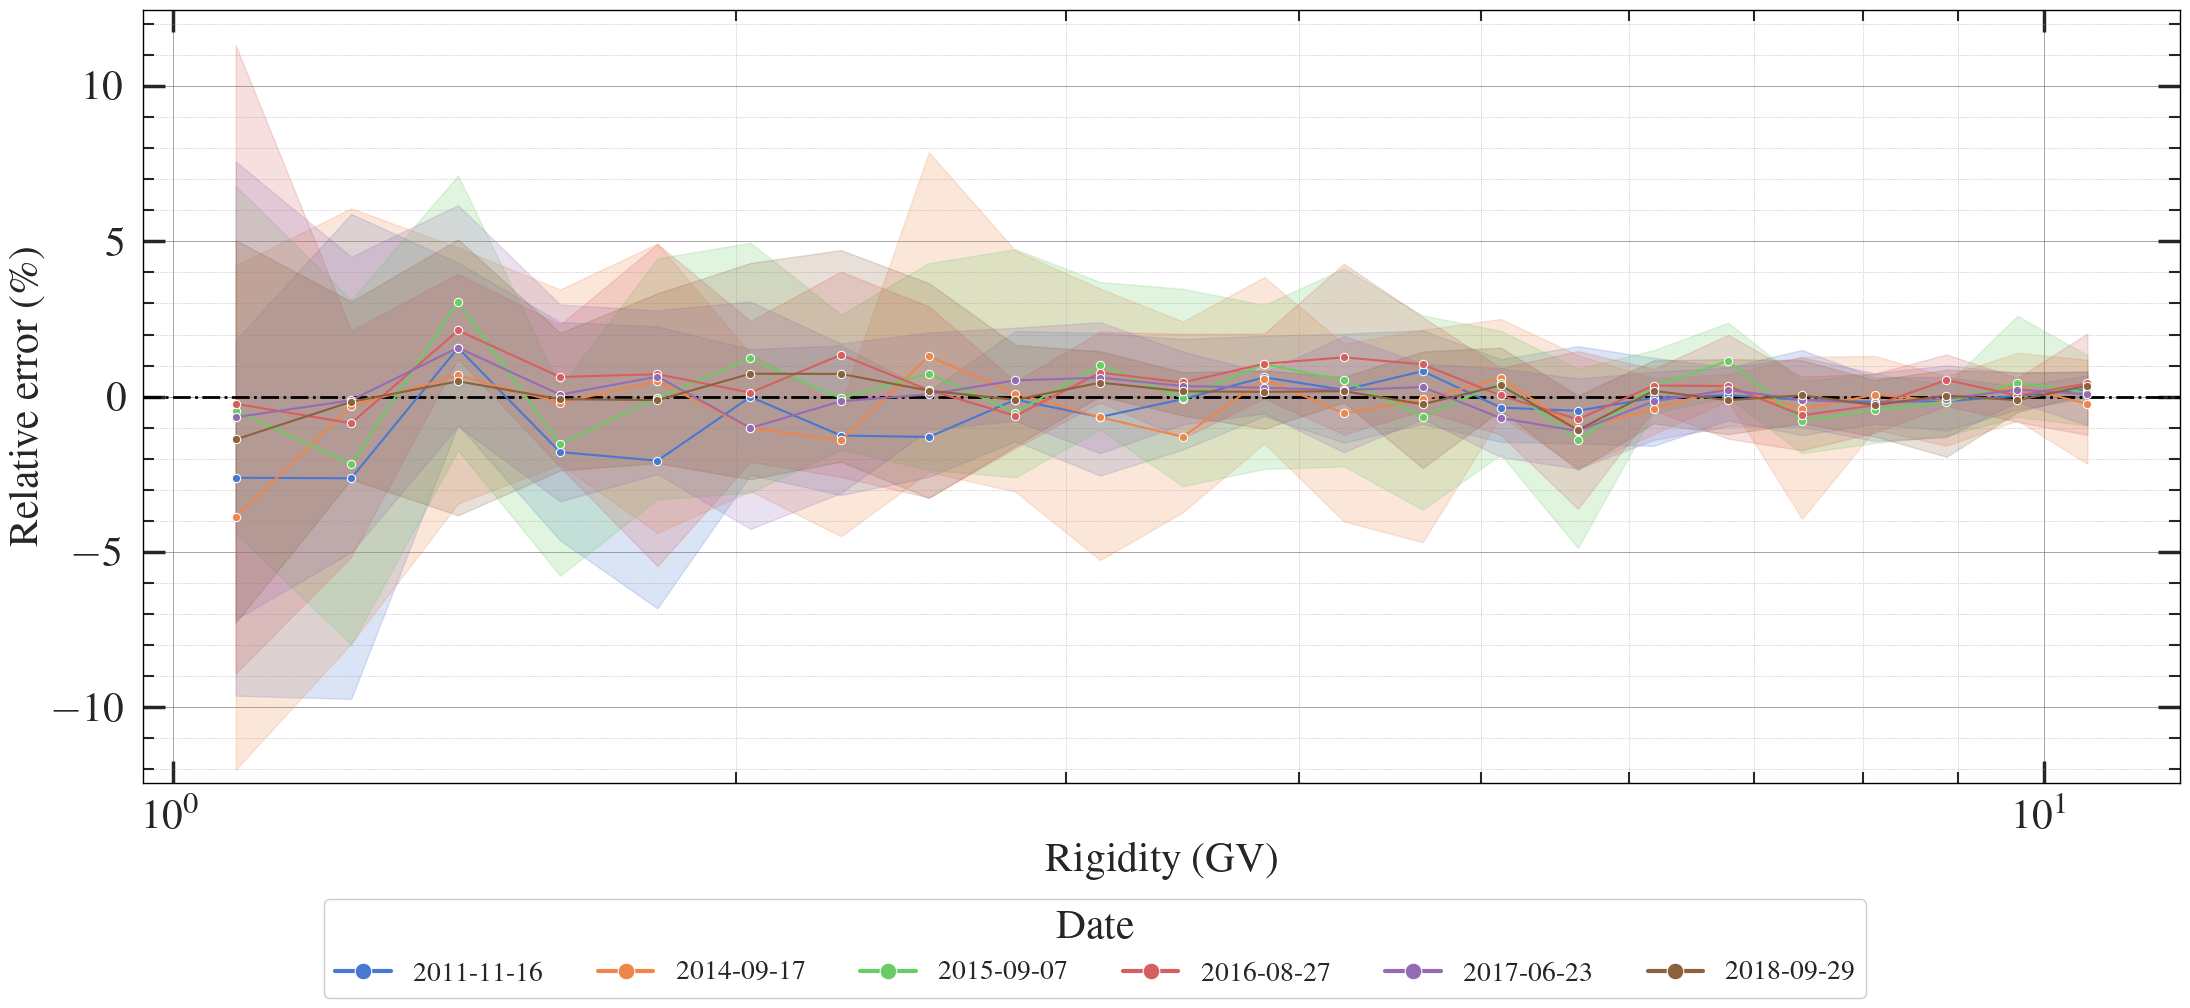

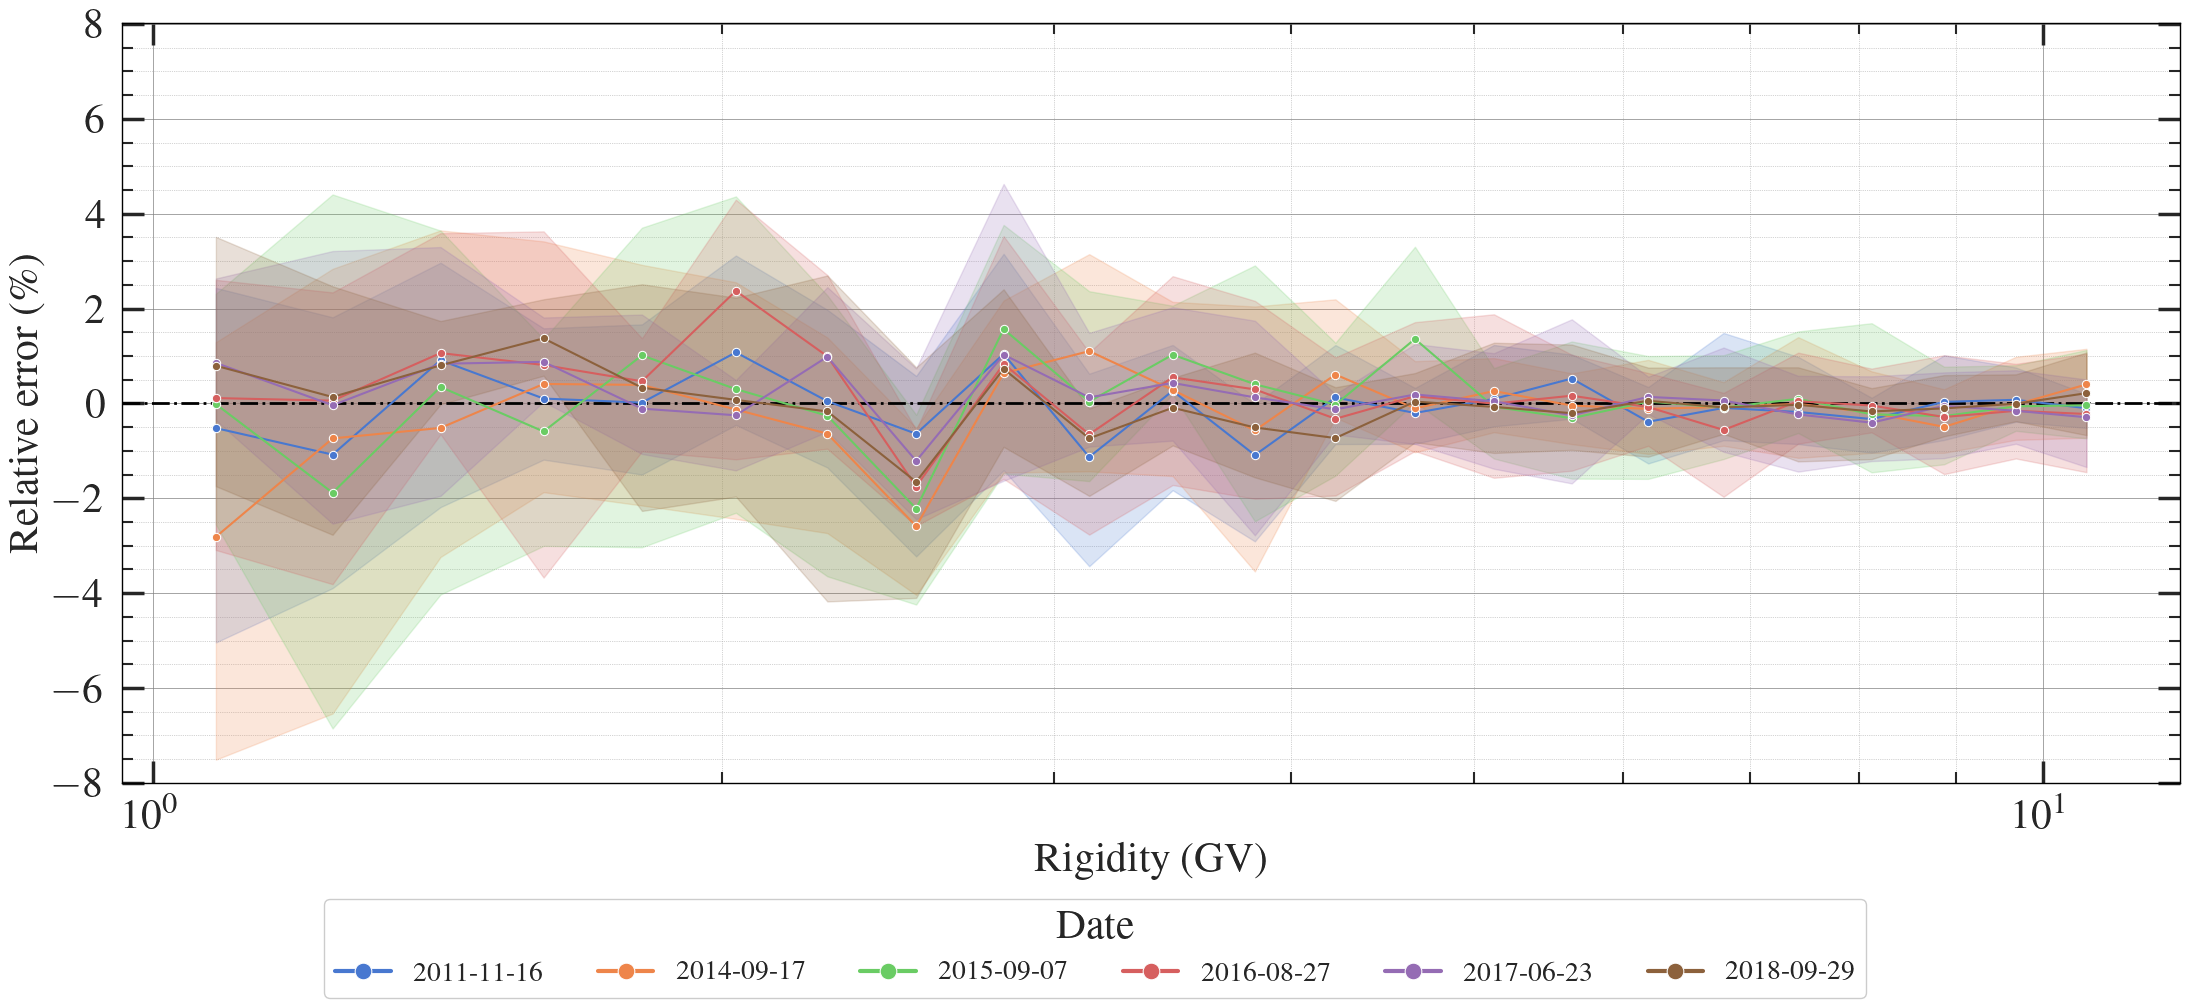

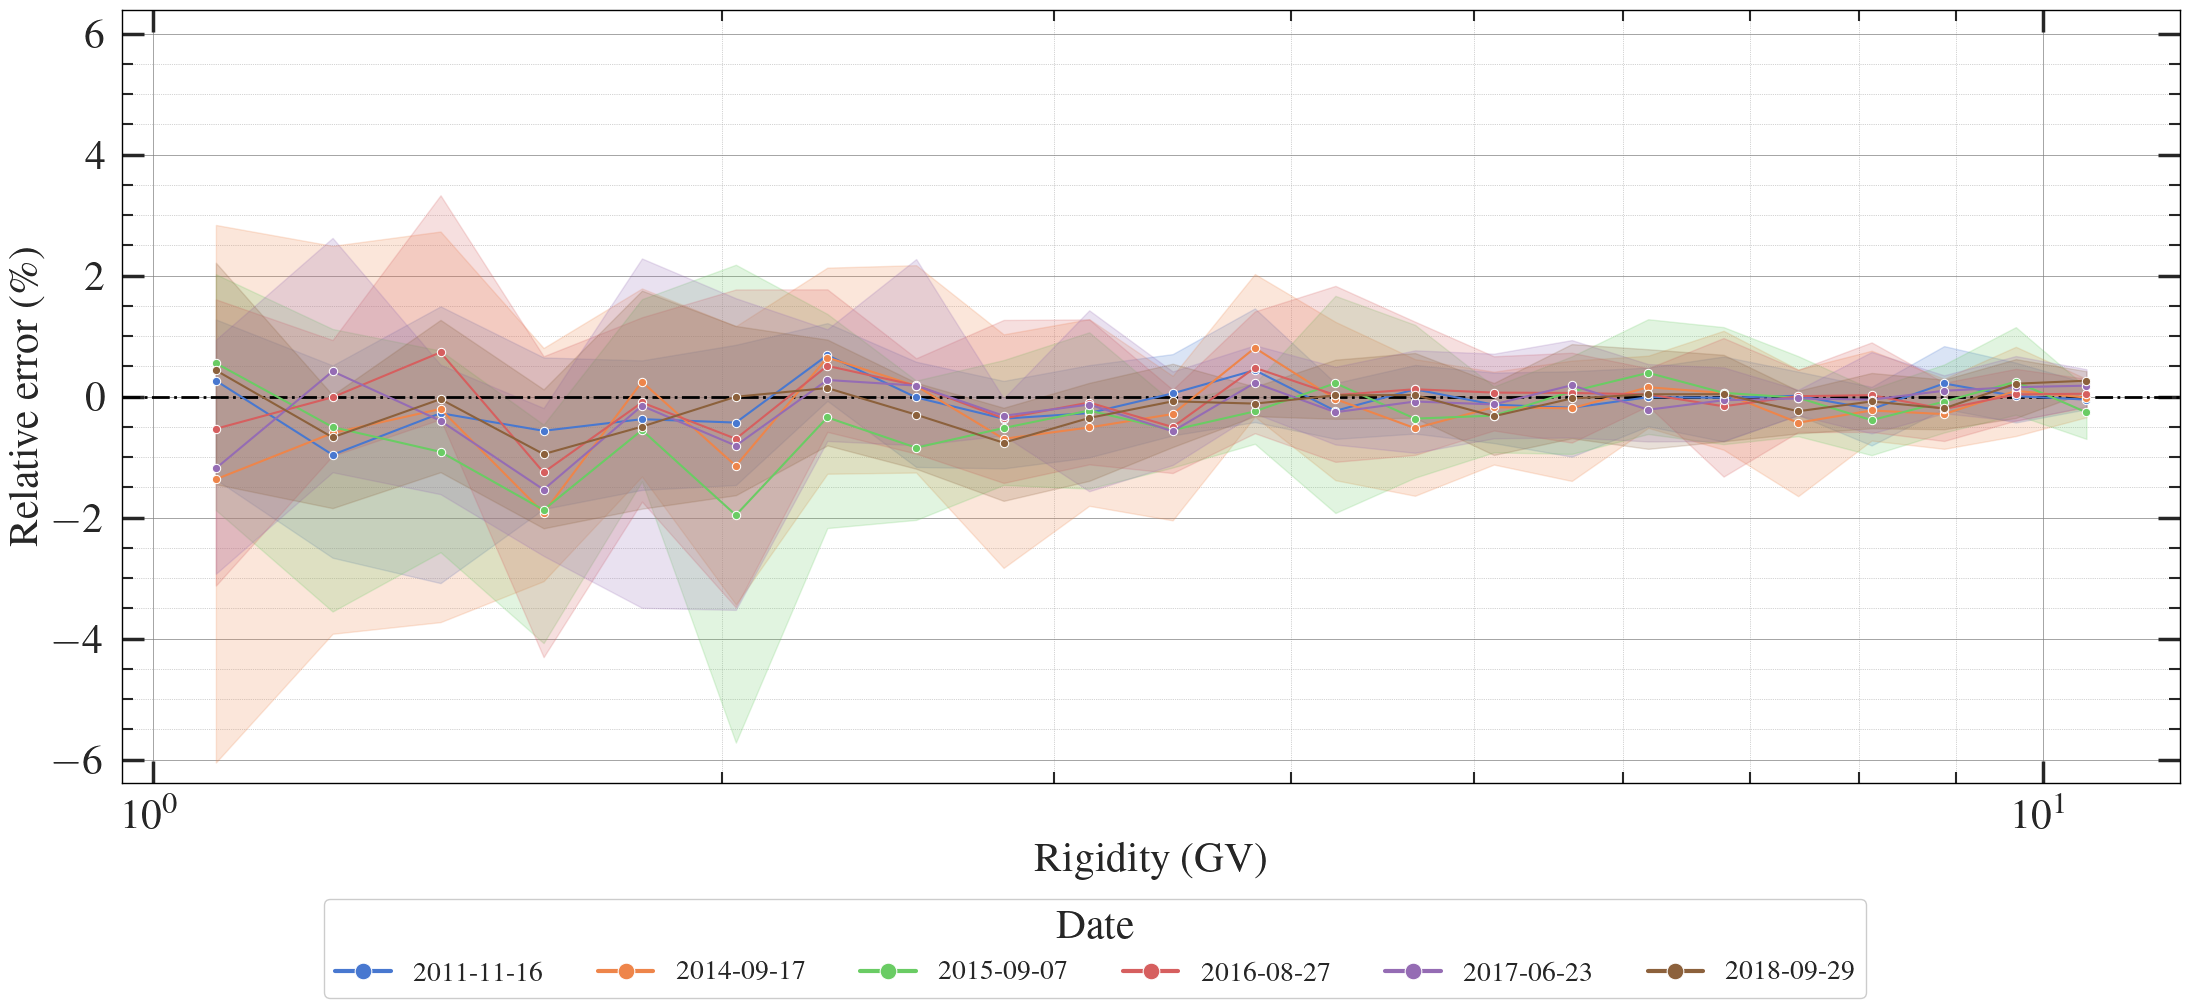

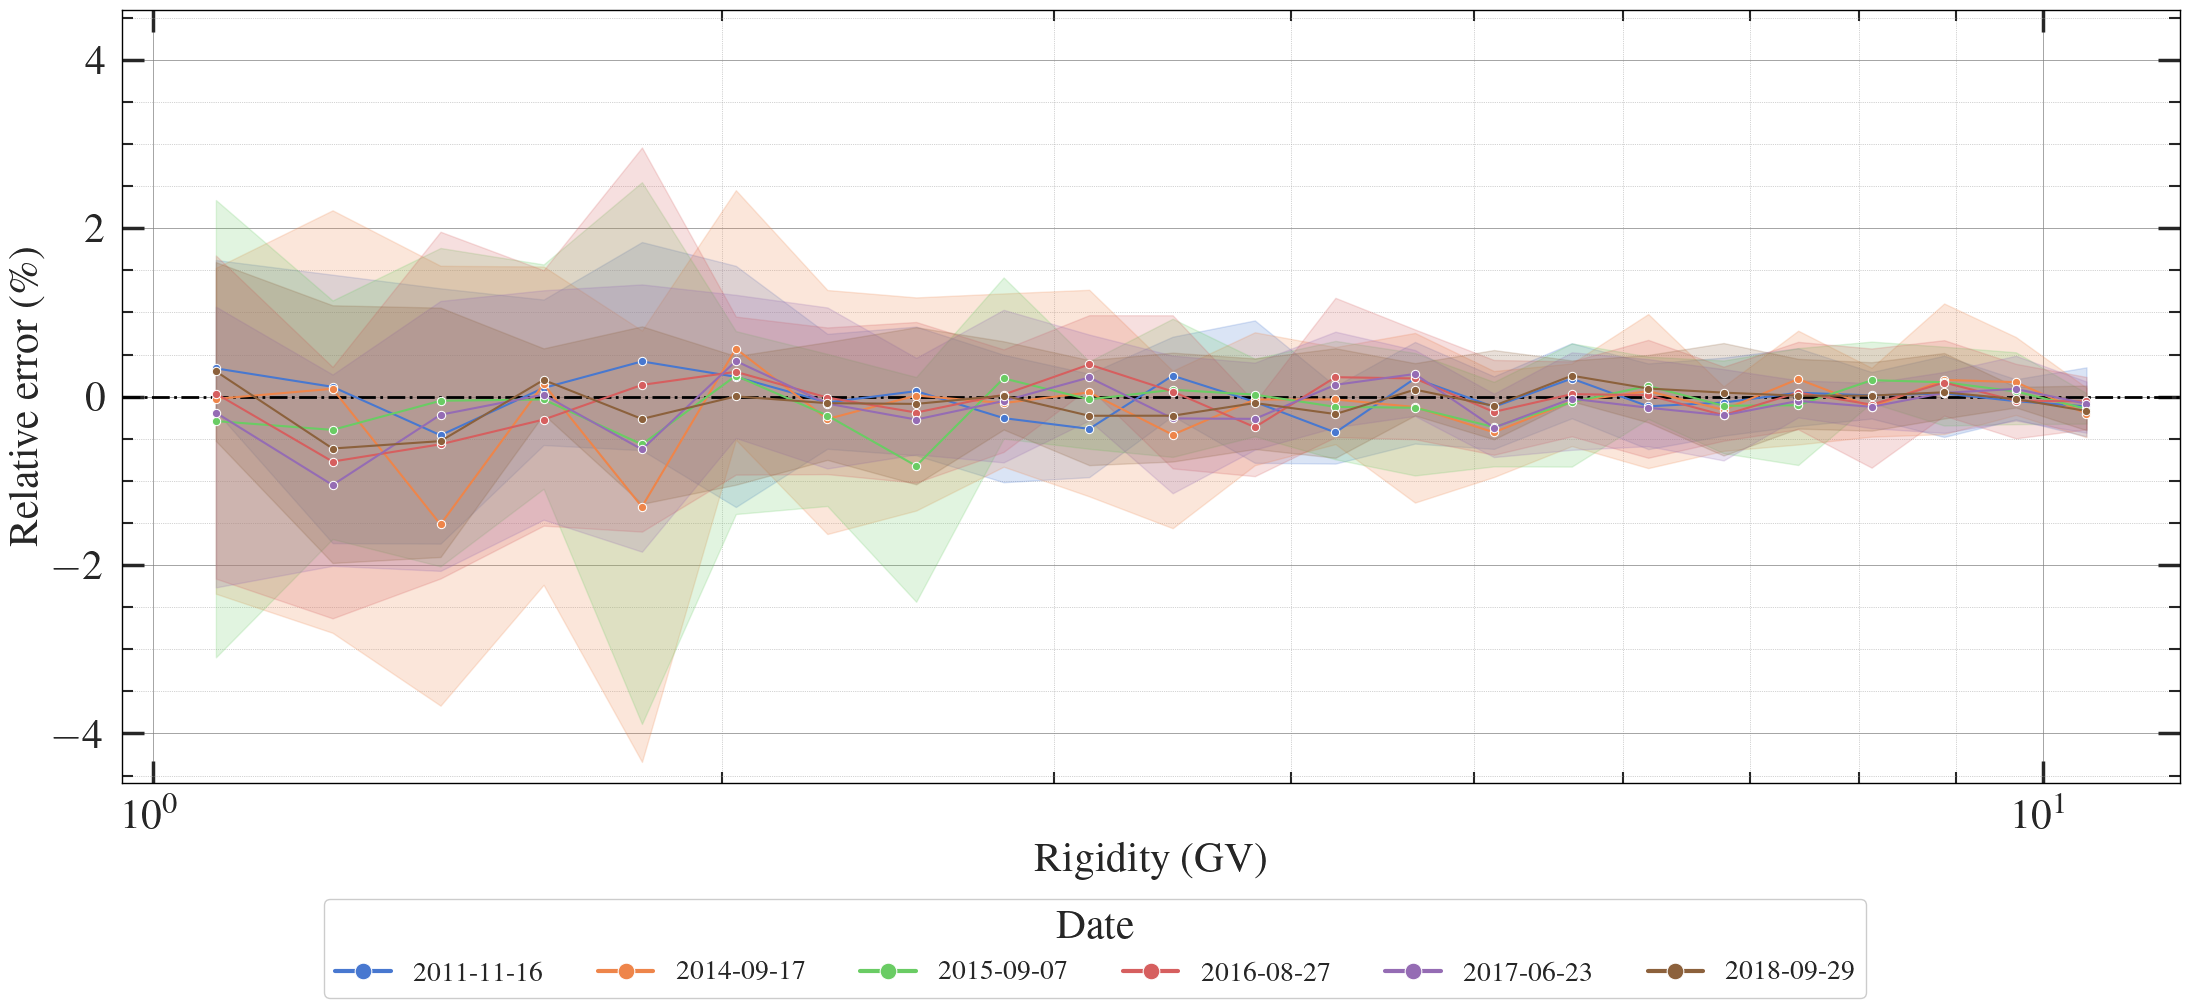

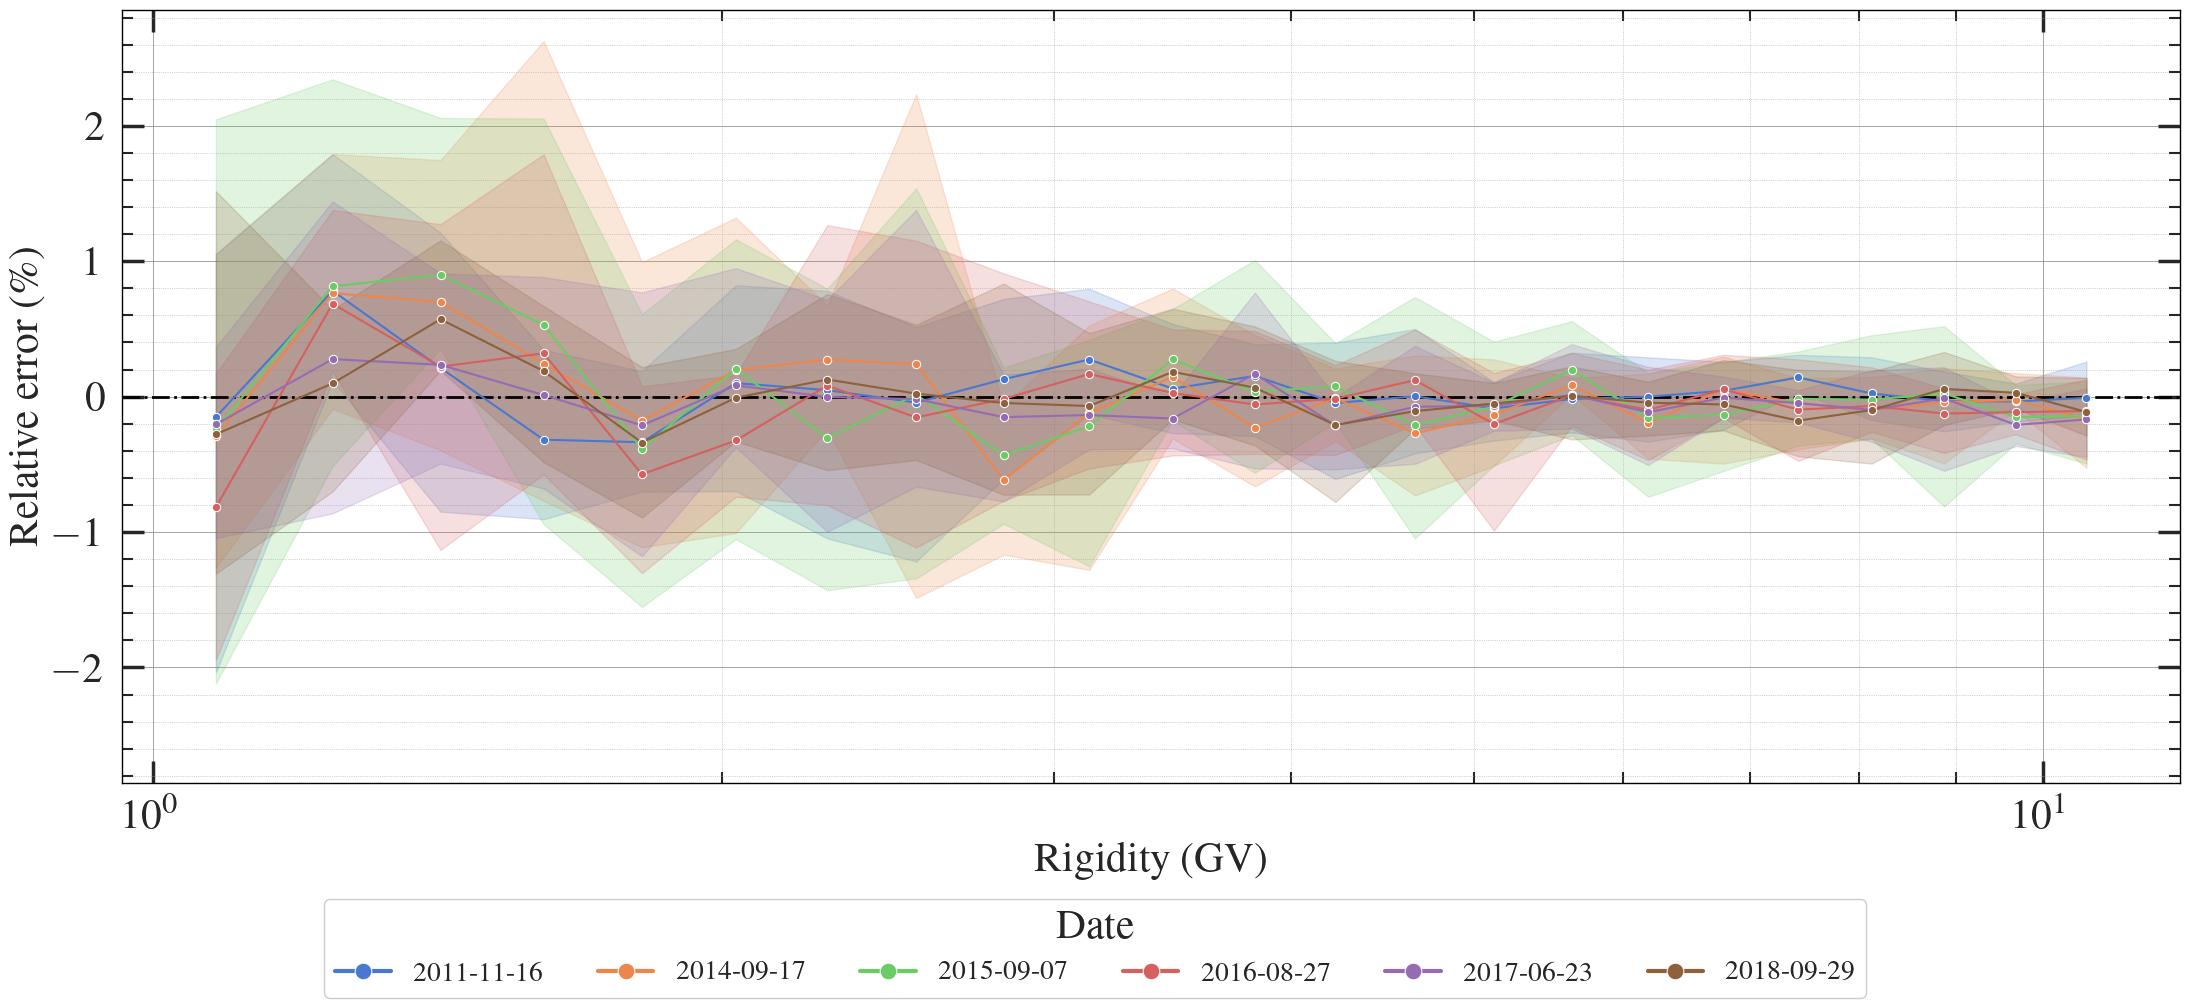

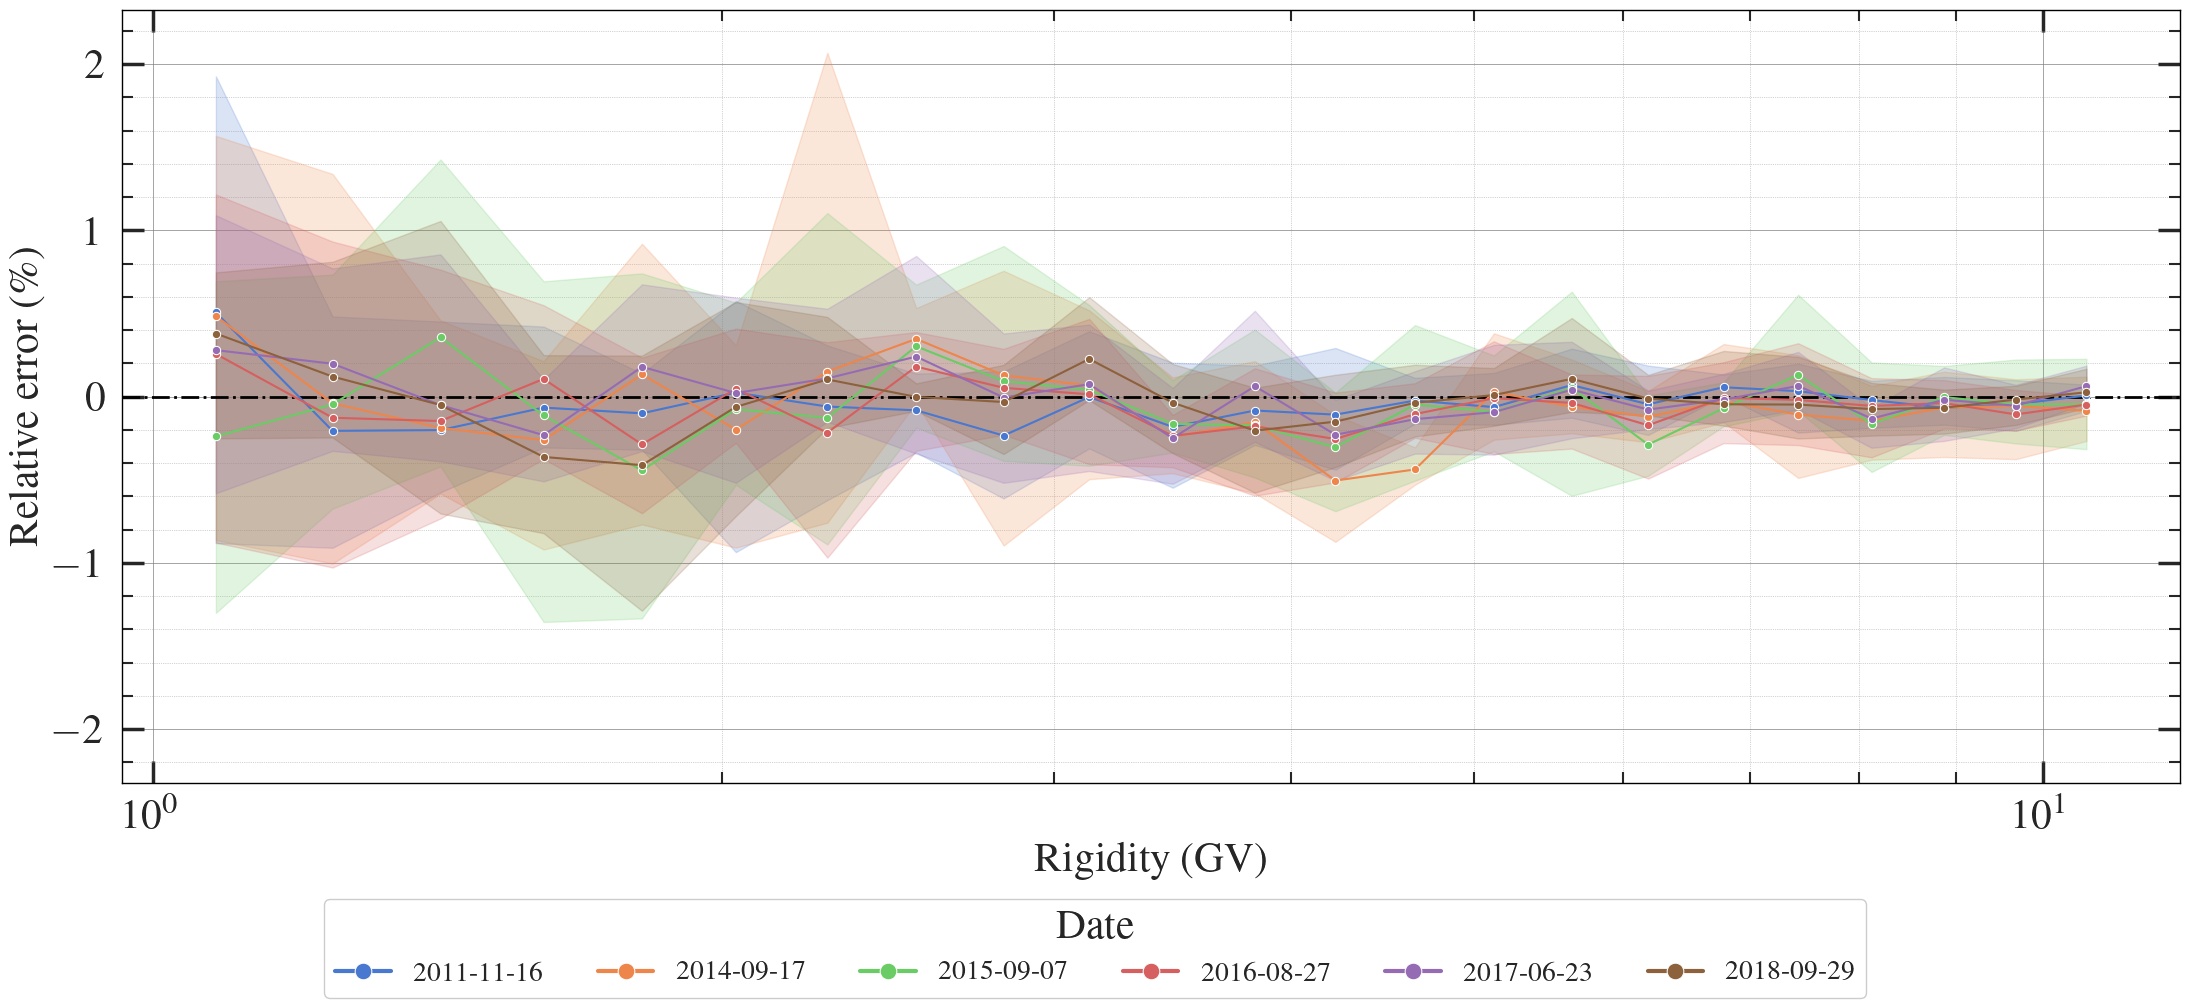

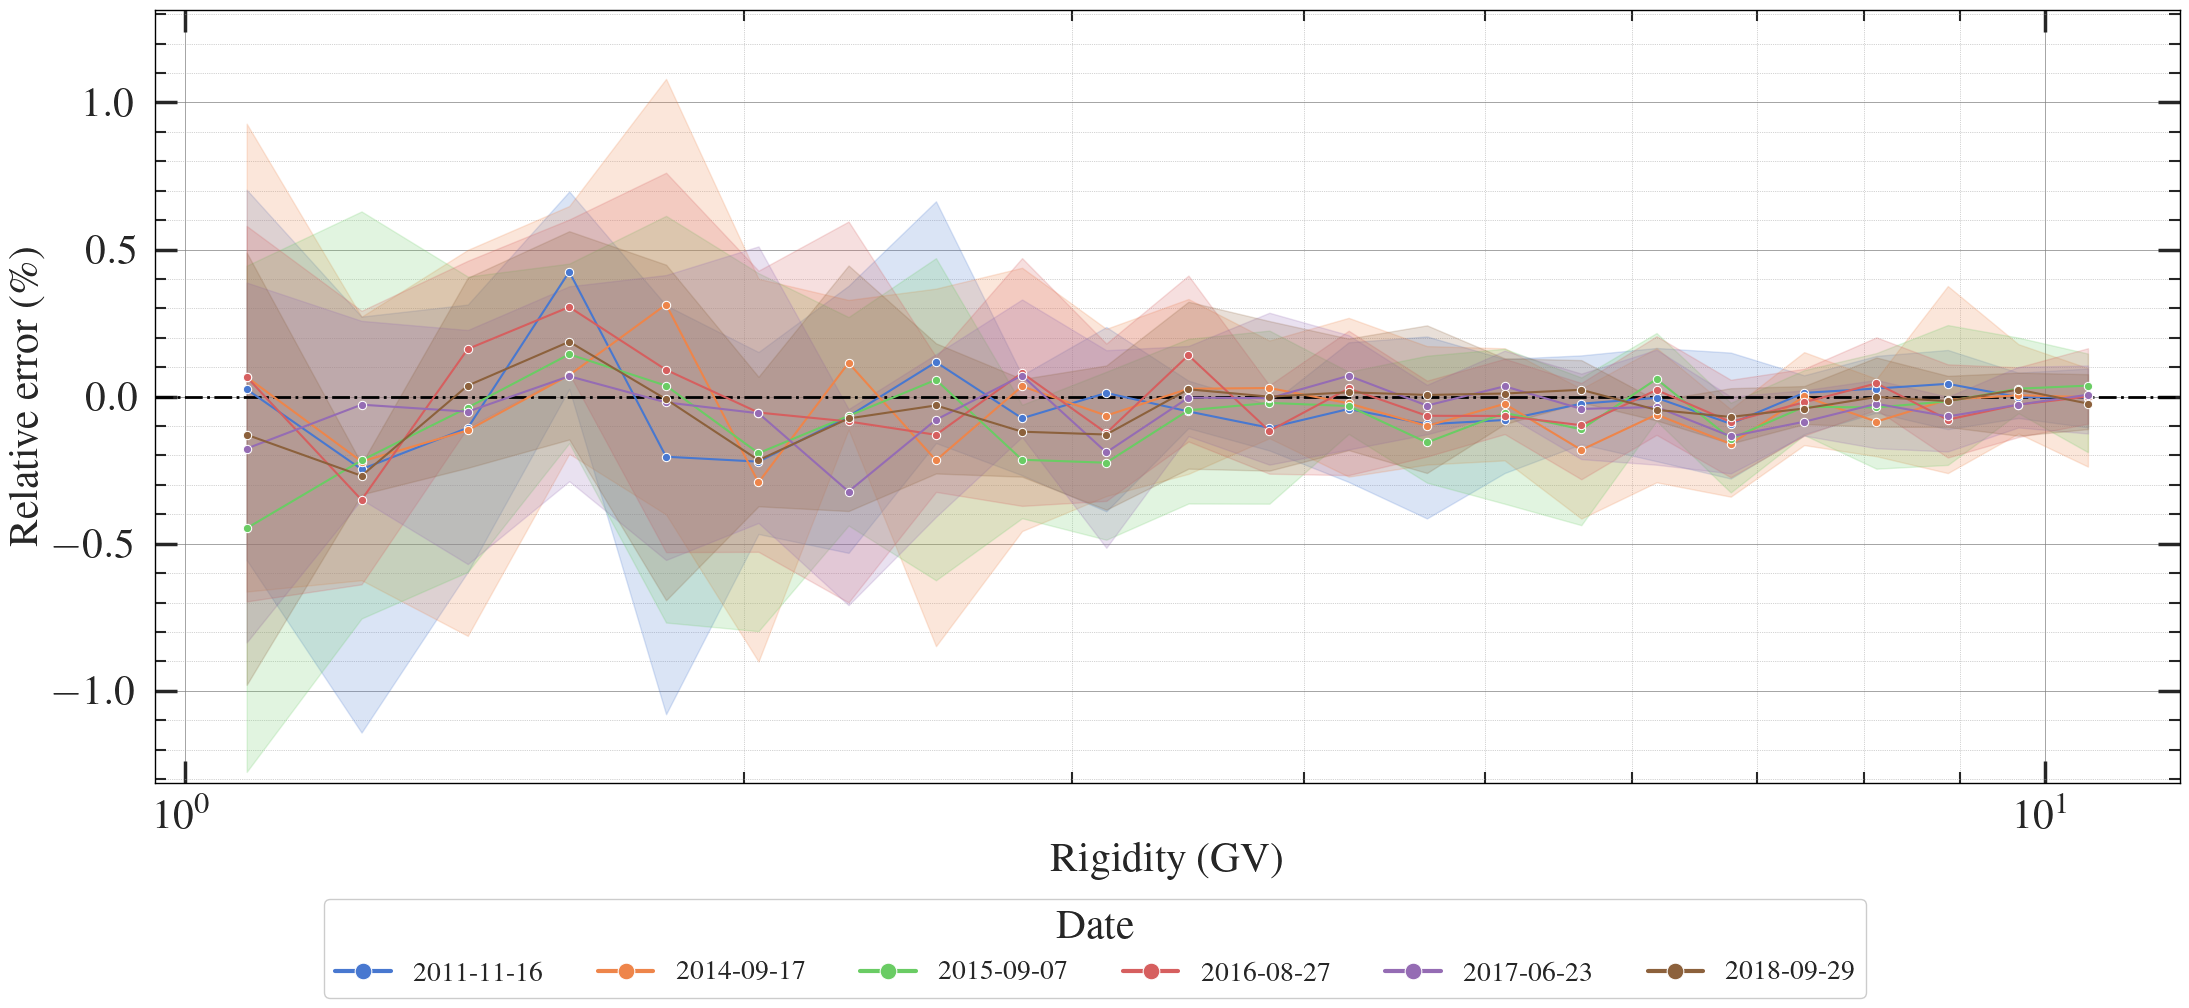

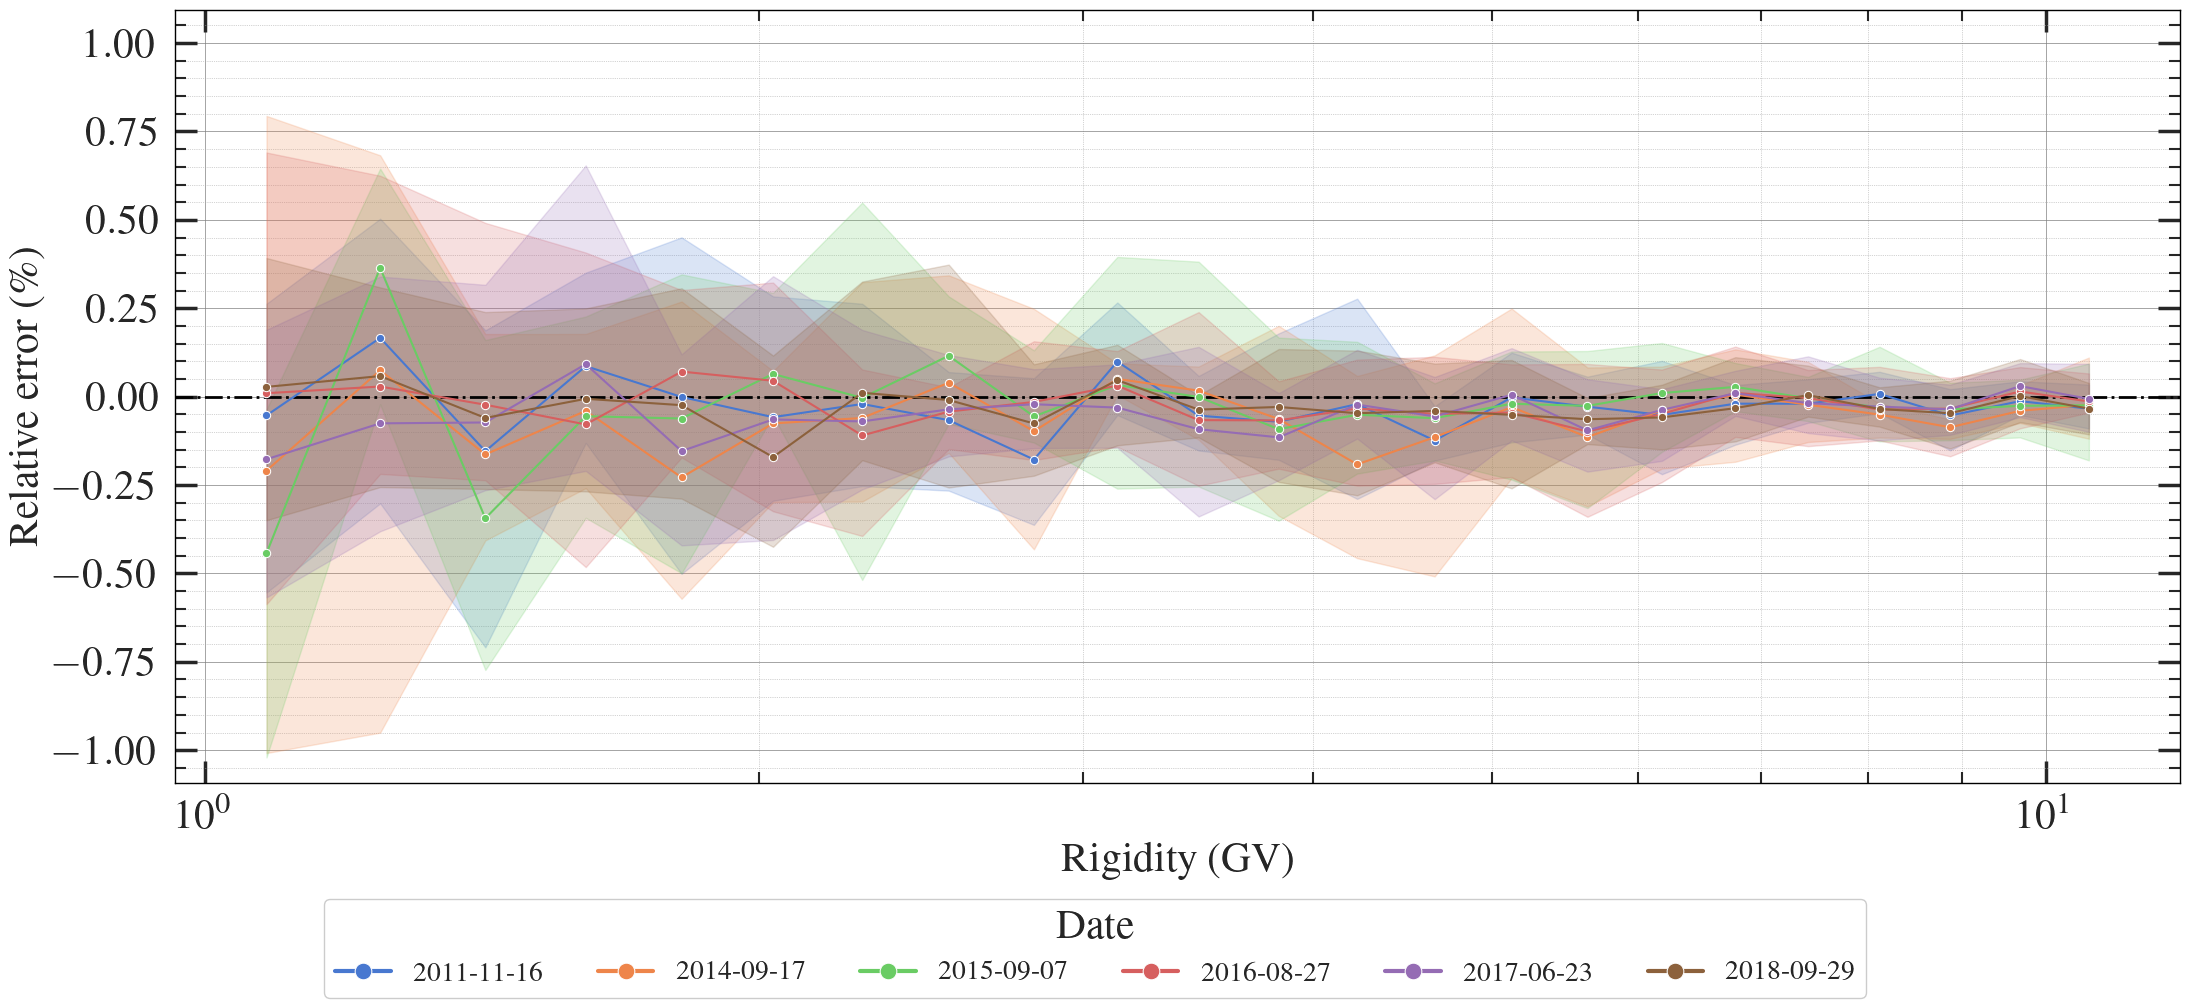

In [6]:
for part in df['val'].unique():
    plot_rigidity_vs_relative_error(part)
    save_plot(f'rigidity_vs_relative_error_{part}')
    plt.show()